지난달 대비 sales_level이 2단계 이상 상승(악화)한 경우 1로 표시

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:\\coding\\bigcontest\\final_df1.csv")
print("🎉 데이터 로딩 성공!")
print(f"데이터 모양 (행, 열): {df.shape}")

print("\n--- 데이터 미리보기 (상위 5개) ---")
display(df.head())

🎉 데이터 로딩 성공!
데이터 모양 (행, 열): (86590, 44)

--- 데이터 미리보기 (상위 5개) ---


,ENCODED_MCT,TA_YM,MCT_OPE_MS_CN,RC_M1_SAA,RC_M1_TO_UE_CT,RC_M1_UE_CUS_CN,RC_M1_AV_NP_AT,APV_CE_RAT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,...,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,is_closed,operating_months,sales_rank_num,customer_rank_num,sales_rank_diff,customer_count_rank_diff
0,000F03E44A,2023-01-01,5_75-90%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,4_50-75%,1_상위1구간,NaN,0.5,...,중식-딤섬/중식만두,뚝섬,2022-02-25,NaN,0,11,6,5,NaN,NaN
1,000F03E44A,2023-02-01,5_75-90%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,NaN,0.0,...,중식-딤섬/중식만두,뚝섬,2022-02-25,NaN,0,12,6,6,0.0,1.0
2,000F03E44A,2023-03-01,5_75-90%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,NaN,0.0,...,중식-딤섬/중식만두,뚝섬,2022-02-25,NaN,0,13,6,6,0.0,0.0
3,000F03E44A,2023-04-01,5_75-90%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,3_25-50%,1_상위1구간,NaN,1.3,...,중식-딤섬/중식만두,뚝섬,2022-02-25,NaN,0,14,6,5,0.0,-1.0
4,000F03E44A,2023-05-01,5_75-90%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,6_90%초과(하위 10% 이하),1_상위1구간,NaN,0.0,...,중식-딤섬/중식만두,뚝섬,2022-02-25,NaN,0,15,6,5,0.0,0.0


In [2]:
print("\n--- 데이터 기본 정보 ---")
df.info()


--- 데이터 기본 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ENCODED_MCT               86590 non-null  object 
 1   TA_YM                     86590 non-null  object 
 2   MCT_OPE_MS_CN             86590 non-null  object 
 3   RC_M1_SAA                 86590 non-null  object 
 4   RC_M1_TO_UE_CT            86590 non-null  object 
 5   RC_M1_UE_CUS_CN           86590 non-null  object 
 6   RC_M1_AV_NP_AT            86590 non-null  object 
 7   APV_CE_RAT                79958 non-null  object 
 8   DLV_SAA_RAT               29245 non-null  float64
 9   M1_SME_RY_SAA_RAT         86590 non-null  float64
 10  M1_SME_RY_CNT_RAT         86590 non-null  float64
 11  M12_SME_RY_SAA_PCE_RT     86590 non-null  float64
 12  M12_SME_BZN_SAA_PCE_RT    86590 non-null  float64
 13  M12_SME_RY_ME_MCT_RAT     86590 non-null  

In [3]:
df.replace(-999999.9, np.nan, inplace=True)

In [4]:
df['TA_YM'] = df['TA_YM'].astype(str)
df['TA_YM'] = pd.to_datetime(df['TA_YM'], errors='coerce')

In [5]:
df = df.sort_values(by=['ENCODED_MCT', 'TA_YM']).reset_index(drop=True)

In [6]:
grouped = df.groupby('ENCODED_MCT')

In [7]:
# 1. 매출 급락 경고 (Sales Drop Warning)
    #    지난달 대비 sales_level이 2단계 이상 상승(악화)한 경우 1로 표시
df['target1_sales_drop'] = (grouped['sales_rank_num'].diff() >= 2).astype(int)


In [8]:
# 2. 충성 고객 이탈 경고 (Loyalty Drop Warning)
    #재방문 고객 비중이 지난달 대비 30% 이상 감소한 경우 1로 표시
df['target2_loyalty_drop'] = (df['MCT_UE_CLN_REU_RAT'] < (grouped['MCT_UE_CLN_REU_RAT'].shift(1) * 0.7)).astype(int)


In [9]:
# 3. 상대적 성과 악화 경고 (Relative Decline Warning)
    #    상권 내 매출 순위 비율이 지난달 대비 10%p 이상 하락한 경우 1로 표시
df['target3_relative_decline'] = ((grouped['M12_SME_BZN_SAA_PCE_RT'].shift(1) - df['M12_SME_BZN_SAA_PCE_RT']) >= 10).astype(int)

In [10]:
print("\n--- 생성된 타겟 변수 분포 ---")
print("1. 매출 급락 경고:", df['target1_sales_drop'].value_counts(normalize=True).map('{:.2%}'.format))
print("\n2. 충성 고객 이탈 경고:", df['target2_loyalty_drop'].value_counts(normalize=True).map('{:.2%}'.format))
print("\n3. 상대적 성과 악화 경고:", df['target3_relative_decline'].value_counts(normalize=True).map('{:.2%}'.format))
    


--- 생성된 타겟 변수 분포 ---
1. 매출 급락 경고: target1_sales_drop
0    98.83%
1     1.17%
Name: proportion, dtype: object

2. 충성 고객 이탈 경고: target2_loyalty_drop
0    99.05%
1     0.95%
Name: proportion, dtype: object

3. 상대적 성과 악화 경고: target3_relative_decline
0    99.17%
1     0.83%
Name: proportion, dtype: object


In [11]:
try:
    df.to_csv('df_3targets.csv', index=False, encoding='utf-8-sig')
    print("🎉 성공! 'df_3targets.csv' 파일로 안전하게 저장했습니다.")
    print("다음부터는 이 파일을 불러와서 사용하시면 됩니다.")
except NameError:
    print("🚨 'df' 데이터프레임이 아직 생성되지 않았습니다. 이전 단계를 먼저 실행해주세요.")
except Exception as e:
    print(f"🚨 파일을 저장하는 중 오류가 발생했습니다: {e}")


🎉 성공! 'df_3targets.csv' 파일로 안전하게 저장했습니다.
다음부터는 이 파일을 불러와서 사용하시면 됩니다.


-------------------------------------------------------------

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [13]:
# 1. 저장했던 데이터 불러오기
df = pd.read_csv('df_3targets.csv')
print("✅ 'df_3targets.csv' 파일 로딩 성공!")

✅ 'df_3targets.csv' 파일 로딩 성공!


In [14]:
if 'sales_rank_diff' in df.columns:
        df = df.drop(columns=['sales_rank_diff'])
        print("✅ 'sales_rank_diff' 칼럼을 성공적으로 삭제했습니다.")
else:
        print("⚠️ 'sales_rank_diff' 칼럼이 데이터에 존재하지 않습니다. 그대로 진행합니다.")

✅ 'sales_rank_diff' 칼럼을 성공적으로 삭제했습니다.


In [15]:
# --- 2. 변수 선택 (Feature Selection) ---
y = df['target1_sales_drop']
X = df.drop(columns=['target1_sales_drop', 'target2_loyalty_drop', 'target3_relative_decline'])

In [16]:
cols_to_drop = [
        'ENCODED_MCT', 'TA_YM', 'MCT_BSE_AR', 'MCT_NM', 'MCT_BRD_NUM', 'ARE_D', 'MCT_ME_D', 'is_closed',
        'RC_M1_SAA', 'sales_rank_num' # 타겟 변수를 만들 때 사용한 원본 변수 제거
    ]
X = X.drop(columns=cols_to_drop)
print(f" 모델 학습에 사용할 변수 {X.shape[1]}개를 선택했습니다.")

 모델 학습에 사용할 변수 33개를 선택했습니다.


In [17]:
 # --- 3. 범주형 / 수치형 변수 구분 ---

categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

print(f"\n- 처리할 문자(범주형) 변수: {len(categorical_features)}개")
print(f"- 처리할 숫자(수치형) 변수: {len(numerical_features)}개")


- 처리할 문자(범주형) 변수: 8개
- 처리할 숫자(수치형) 변수: 25개


In [18]:
# --- 4. 결측치 처리 (Imputation) ---
#중앙값으로 채움움
imputer = SimpleImputer(strategy='median')
X[numerical_features] = imputer.fit_transform(X[numerical_features])
print("\n 숫자 변수의 결측치를 '중앙값'으로 모두 채웠습니다.")



 숫자 변수의 결측치를 '중앙값'으로 모두 채웠습니다.


In [19]:
 # --- 5. 범주형 변수 변환 (One-Hot Encoding) ---

X = pd.get_dummies(X, columns=categorical_features, dummy_na=True)
print("✅ 문자 변수를 원-핫 인코딩으로 모두 숫자로 변환했습니다.")


✅ 문자 변수를 원-핫 인코딩으로 모두 숫자로 변환했습니다.


In [20]:
# --- 최종 데이터 확인 ---
print(f"\n🎉 최종 모델링 데이터 준비 완료! (행: {X.shape[0]}, 열: {X.shape[1]})")
    
print(f"남아있는 결측치 개수: {X.isnull().sum().sum()}")


🎉 최종 모델링 데이터 준비 완료! (행: 86590, 열: 158)
남아있는 결측치 개수: 0


—————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————



베이스라인 모델을 만들기 전에 ３４개의 변수를 전부 써서 한번 학습해보고、 그중에서 높은 관계를 보이는 변수들만 채택할 예정


In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
#한글설정

In [23]:
#데이터 나누기기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n✅ 훈련 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")



✅ 훈련 데이터: (69272, 158), 테스트 데이터: (17318, 158)


In [24]:
#모델 학습, 생성
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
    
model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight, # 불균형 데이터 처리
        random_state=42
    )

In [25]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [26]:
y_pred = model.predict(X_test)

In [27]:
print("\n--- 모델 성능 평가 (테스트 데이터) ---")

print(classification_report(y_test, y_pred, target_names=['정상 (0)', '매출급락 (1)']))



--- 모델 성능 평가 (테스트 데이터) ---
              precision    recall  f1-score   support

      정상 (0)       1.00      0.99      0.99     17115
    매출급락 (1)       0.43      0.60      0.50       203

    accuracy                           0.99     17318
   macro avg       0.71      0.79      0.75     17318
weighted avg       0.99      0.99      0.99     17318



<Axes: ylabel='None'>

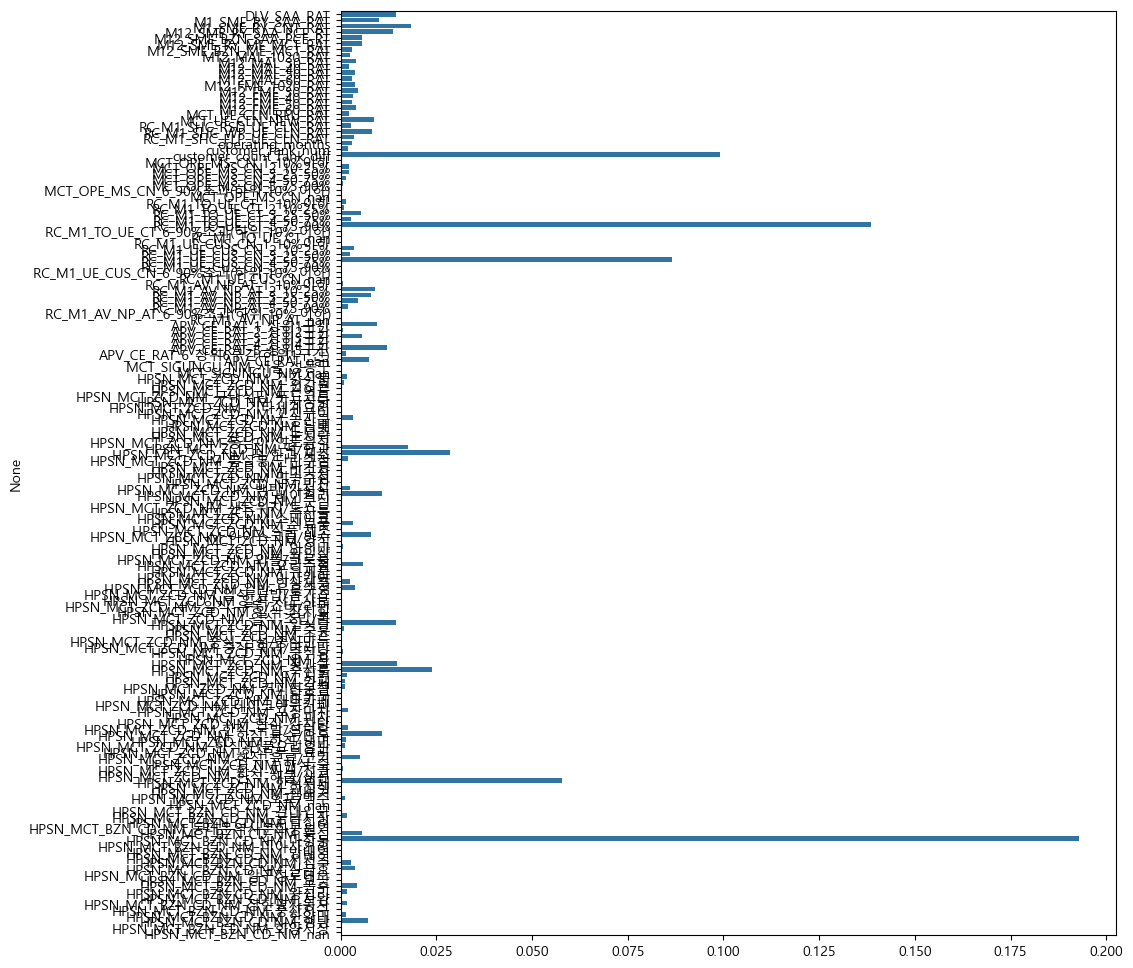

In [28]:
 # 변수 중요도(Feature Importance) 시각화
plt.figure(figsize=(10, 12))
sns.barplot(x=model.feature_importances_, y=X.columns)

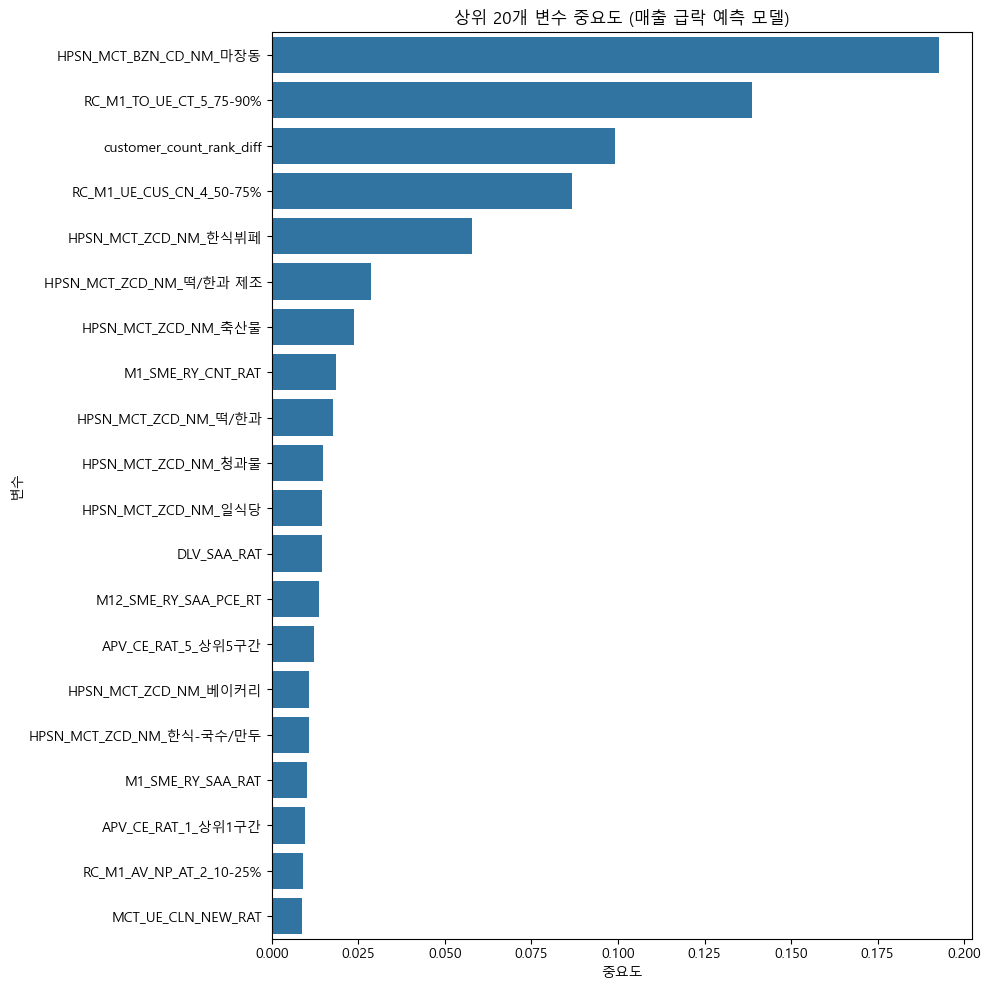

In [29]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    
plt.figure(figsize=(10, 10))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title('상위 20개 변수 중요도 (매출 급락 예측 모델)')
plt.xlabel('중요도')
plt.ylabel('변수')
plt.tight_layout()
plt.show()

이제 이 독립변수들 중에서 가장 큰 N개를 선택해서 머신러닝을 돌릴거임


In [30]:

# 1. 학습된 모델(model)에서 변수 중요도 정보 가져오기
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# 2. 중요도 순으로 정렬하고 상위 15개 선택
N = 15
top_n_features = feature_importances.sort_values(ascending=False).head(N)

print(f"---  '매출 급락' 예측 핵심 변수 TOP {N} ---")
print(top_n_features)

# 3. 선택된 변수들의 이름을 리스트로 저장
#    이 리스트를 다음 모델 학습에 바로 사용할 수 있습니다.
list_of_top_n_features = top_n_features.index.tolist()
print("\n--- 다음 모델링에 사용할 변수 목록 ---")
print(list_of_top_n_features)


---  '매출 급락' 예측 핵심 변수 TOP 15 ---
HPSN_MCT_BZN_CD_NM_마장동      0.192787
RC_M1_TO_UE_CT_5_75-90%     0.138645
customer_count_rank_diff    0.099087
RC_M1_UE_CUS_CN_4_50-75%    0.086588
HPSN_MCT_ZCD_NM_한식뷔페        0.057955
HPSN_MCT_ZCD_NM_떡/한과 제조     0.028508
HPSN_MCT_ZCD_NM_축산물         0.023780
M1_SME_RY_CNT_RAT           0.018388
HPSN_MCT_ZCD_NM_떡/한과        0.017665
HPSN_MCT_ZCD_NM_청과물         0.014652
HPSN_MCT_ZCD_NM_일식당         0.014399
DLV_SAA_RAT                 0.014367
M12_SME_RY_SAA_PCE_RT       0.013608
APV_CE_RAT_5_상위5구간          0.012115
HPSN_MCT_ZCD_NM_베이커리        0.010798
dtype: float32

--- 다음 모델링에 사용할 변수 목록 ---
['HPSN_MCT_BZN_CD_NM_마장동', 'RC_M1_TO_UE_CT_5_75-90%', 'customer_count_rank_diff', 'RC_M1_UE_CUS_CN_4_50-75%', 'HPSN_MCT_ZCD_NM_한식뷔페', 'HPSN_MCT_ZCD_NM_떡/한과 제조', 'HPSN_MCT_ZCD_NM_축산물', 'M1_SME_RY_CNT_RAT', 'HPSN_MCT_ZCD_NM_떡/한과', 'HPSN_MCT_ZCD_NM_청과물', 'HPSN_MCT_ZCD_NM_일식당', 'DLV_SAA_RAT', 'M12_SME_RY_SAA_PCE_RT', 'APV_CE_RAT_5_상위5구간', 'HPSN_MCT_ZCD_NM_베이커리']


In [31]:
 # 최종 X 칼럼에 존재하는 변수들만 선택합니다.
final_top_features = [col for col in list_of_top_n_features if col in X.columns]
X_simple = X[final_top_features]
print(f"\n✅ 핵심 변수 {len(X_simple.columns)}개를 선택하여 '단순 모델'을 준비했습니다.")



✅ 핵심 변수 15개를 선택하여 '단순 모델'을 준비했습니다.


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42, stratify=y)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
model_simple = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )

In [33]:
model_simple.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:
y_pred = model_simple.predict(X_test)
print("\n--- 📊 '단순 모델' 성능 평가 (Top 15 변수 사용) ---")
print(classification_report(y_test, y_pred, target_names=['정상 (0)', '매출급락 (1)']))



--- 📊 '단순 모델' 성능 평가 (Top 15 변수 사용) ---
              precision    recall  f1-score   support

      정상 (0)       1.00      0.95      0.98     17115
    매출급락 (1)       0.16      0.72      0.26       203

    accuracy                           0.95     17318
   macro avg       0.58      0.84      0.62     17318
weighted avg       0.99      0.95      0.97     17318



recall은 0.6 -> 0.72

f1score은 0.5 -> 0.26 

하이퍼파라미터 튜닝 해보기


_____________________________________________________________________________

In [35]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

In [36]:
list_of_top_n_features = [
    'HPSN_MCT_BZN_CD_NM_마장동', 'RC_M1_TO_UE_CT_5_75-90%', 'customer_count_rank_diff', 'RC_M1_UE_CUS_CN_4_50-75%', 'HPSN_MCT_ZCD_NM_한식뷔페', 'HPSN_MCT_ZCD_NM_떡/한과 제조', 'HPSN_MCT_ZCD_NM_축산물', 'M1_SME_RY_CNT_RAT', 'HPSN_MCT_ZCD_NM_떡/한과', 'HPSN_MCT_ZCD_NM_청과물', 'HPSN_MCT_ZCD_NM_일식당', 'DLV_SAA_RAT', 'M12_SME_RY_SAA_PCE_RT', 'APV_CE_RAT_5_상위5구간', 'HPSN_MCT_ZCD_NM_베이커리'
]

In [37]:
df = pd.read_csv('df_3targets.csv')
df.replace(-999999.9, np.nan, inplace=True)
    
y = df['target1_sales_drop']

In [38]:
# 일단 모든 변수를 X로 선택
X = df.drop(columns=['target1_sales_drop', 'target2_loyalty_drop', 'target3_relative_decline', 'sales_rank_diff'])

In [39]:
cols_to_drop = [
        'ENCODED_MCT', 'TA_YM', 'MCT_BSE_AR', 'MCT_NM', 'MCT_BRD_NUM', 'ARE_D', 'MCT_ME_D', 'is_closed',
        'RC_M1_SAA', 'sales_level'
    ]
X = X.drop(columns=[col for col in cols_to_drop if col in X.columns])

In [40]:
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
X[numerical_features] = imputer.fit_transform(X[numerical_features])
X = pd.get_dummies(X, columns=categorical_features, dummy_na=True)
#원 핫 인코딩딩

In [41]:
final_top_features = [col for col in list_of_top_n_features if col in X.columns]
X_simple = X[final_top_features]
print(f"\n✅ 핵심 변수 {len(X_simple.columns)}개를 선택하여 튜닝을 준비합니다.")


✅ 핵심 변수 15개를 선택하여 튜닝을 준비합니다.


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42, stratify=y)
    
param_dist = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5, 6],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
    }
    
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=42)
    
random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=20, scoring='f1', cv=3, random_state=42, n_jobs=-1, verbose=1)

print("\n⏳ 하이퍼파라미터 튜닝 시작 (시간이 다소 소요될 수 있습니다)...")
random_search.fit(X_train, y_train)
print("🎉 튜닝 완료!")


⏳ 하이퍼파라미터 튜닝 시작 (시간이 다소 소요될 수 있습니다)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
🎉 튜닝 완료!


In [43]:
print("\n--- 🏆 최적의 하이퍼파라미터 ---")
print(random_search.best_params_)


--- 🏆 최적의 하이퍼파라미터 ---
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [44]:
print("\n--- 📊 튜닝된 모델 최종 성능 평가 ---")
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['정상 (0)', '매출급락 (1)']))


--- 📊 튜닝된 모델 최종 성능 평가 ---
              precision    recall  f1-score   support

      정상 (0)       1.00      0.93      0.96     17115
    매출급락 (1)       0.12      0.80      0.22       203

    accuracy                           0.93     17318
   macro avg       0.56      0.87      0.59     17318
weighted avg       0.99      0.93      0.96     17318

